# Step 7: Evaluasi Model

Menggunakan **7 indikator evaluasi** sesuai C23 paper (Tabel 4):

| Indikator | Definisi |
|-----------|----------|
| **MS** | Most Suitable: suit DAN kategori tepat |
| **SCA** | Same Category Acceptable: kategori sama, suit beda tapi wajar |
| **SCU** | Same Category Unacceptable: kategori sama, suit tidak ideal |
| **SSE** | Same Suit Excl. MS: suit sama, kategori beda |
| **O** | Others: sama sekali tidak cocok |
| **SC** | Same Category = MS+SCA+SCU ← **METRIK UTAMA** (target ≥ 0.773) |
| **SS** | Same Suit = MS+SSE |

**Prasyarat:** Jalankan `05_dataset.ipynb` dan `06_training.ipynb` terlebih dahulu.

In [1]:
import sys
import os

ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
sys.path.insert(0, os.path.join(ROOT, "src"))

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from IPython.display import Image, display

DATA_PROCESSED = Path(ROOT) / "data" / "processed"
RESULTS        = Path(ROOT) / "results"

SPLIT_PATH  = RESULTS / "metrics" / "dataset_split.pkl"
MODEL_PATH  = RESULTS / "metrics" / "rf_model.pkl"
FIGURES_DIR = RESULTS / "figures"
METRICS_DIR = RESULTS / "metrics"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

# Override path di modul evaluate agar mengarah ke direktori proyek
import evaluate as ev_module
ev_module.FIGURES_DIR = FIGURES_DIR
ev_module.METRICS_DIR = METRICS_DIR

print(f"Root proyek : {ROOT}")
print("Setup selesai.")

Root proyek : d:\SkripsiBBO
Setup selesai.


## 7.1 Load Model dan Data Test

In [2]:
from model import load_model
from features import FEATURE_COLS
from model import prepare_features
from sklearn.model_selection import train_test_split

# Load model
model = load_model(MODEL_PATH)
print(f"Model dimuat dari: {MODEL_PATH}")

# Load split
if SPLIT_PATH.exists():
    split_data   = joblib.load(SPLIT_PATH)
    X_test       = split_data["X_test"]
    y_suit_test  = split_data["y_suit_test"]
    y_cat_test   = split_data["y_cat_test"]
    X_train      = split_data["X_train"]
    y_suit_train = split_data["y_suit_train"]
    y_cat_train  = split_data["y_cat_train"]
    print(f"Split data dimuat: test={X_test.shape[0]} sampel")
else:
    DATASET_CSV = DATA_PROCESSED / "bridge_dataset.csv"
    df = pd.read_csv(DATASET_CSV).dropna(subset=["best_contract_strain", "best_contract_category"])
    available_feat = [c for c in FEATURE_COLS if c in df.columns]
    X      = prepare_features(df, available_feat)
    y_suit = df["best_contract_strain"]
    y_cat  = df["best_contract_category"]
    X_train, X_test, y_suit_train, y_suit_test = train_test_split(
        X, y_suit, test_size=0.2, stratify=y_suit, random_state=42
    )
    _, _, y_cat_train, y_cat_test = train_test_split(
        X, y_cat, test_size=0.2, stratify=y_suit, random_state=42
    )
    print("Split direkonstruksi dari dataset CSV")

Model dimuat dari: d:\SkripsiBBO\results\metrics\rf_model.pkl
Split data dimuat: test=1154 sampel


## 7.2 Evaluasi Lengkap: 7 Indikator + Confusion Matrix

In [3]:
from evaluate import evaluate

print("Evaluasi model di test set...")
metrics = evaluate(
    model=model,
    X_test=X_test,
    y_suit_test=y_suit_test,
    y_cat_test=y_cat_test,
    model_name="TwoStageRF",
    save_figures=True,
)

Evaluasi model di test set...

  7-INDIKATOR EVALUASI (C23 Tabel 4)
  MS              0.6369  ███████████████████
  SCA             0.1473  ████ ← METRIK UTAMA
  SCU             0.0000   ← METRIK UTAMA
  SSE             0.1222  ███
  O               0.0936  ██
  SC (utama)      0.7842  ███████████████████████ ← METRIK UTAMA
  SS              0.7591  ██████████████████████

  Target SC paper: 0.773 | Hasil: 0.7842

  Stage 1 (Suit)     F1=0.7588  Acc=0.7591
  Stage 2 (Category) F1=0.7830  Acc=0.7842
  Confusion matrix disimpan: d:\SkripsiBBO\results\figures\confusion_matrix_TwoStageRF_suit.png
  Confusion matrix disimpan: d:\SkripsiBBO\results\figures\confusion_matrix_TwoStageRF_category.png
  Feature importance disimpan: d:\SkripsiBBO\results\figures\feature_importance_TwoStageRF.png


## 7.3 Ringkasan Metrik

In [4]:
print("\n=== RINGKASAN METRIK ===")
print(f"SC (Same Category) — METRIK UTAMA : {metrics['sc_accuracy']:.4f}")
print(f"SS (Same Suit)                    : {metrics['ss_accuracy']:.4f}")
print(f"MS (Most Suitable / exact match)  : {metrics['ms_accuracy']:.4f}")
print(f"Stage 1 Suit F1 (weighted)        : {metrics['suit_f1']:.4f}")
print(f"Stage 2 Category F1 (weighted)    : {metrics['category_f1']:.4f}")

paper_sc = 0.773
our_sc   = metrics["sc_accuracy"]
diff     = our_sc - paper_sc
status   = "LEBIH BAIK" if diff > 0 else "DI BAWAH"
print(f"\nSC vs target paper ({paper_sc}): {diff:+.4f} → {status}")


=== RINGKASAN METRIK ===
SC (Same Category) — METRIK UTAMA : 0.7842
SS (Same Suit)                    : 0.7591
MS (Most Suitable / exact match)  : 0.6369
Stage 1 Suit F1 (weighted)        : 0.7588
Stage 2 Category F1 (weighted)    : 0.7830

SC vs target paper (0.773): +0.0112 → LEBIH BAIK


## 7.4 Bar Chart 7 Indikator

In [5]:
from evaluate import plot_indicator_bar
plot_indicator_bar(metrics["indicators"], model_name="TwoStageRF")

  Indicator chart disimpan: d:\SkripsiBBO\results\figures\indicators_TwoStageRF.png


## 7.5 Confusion Matrix

Confusion Matrix — Stage 1: Suit


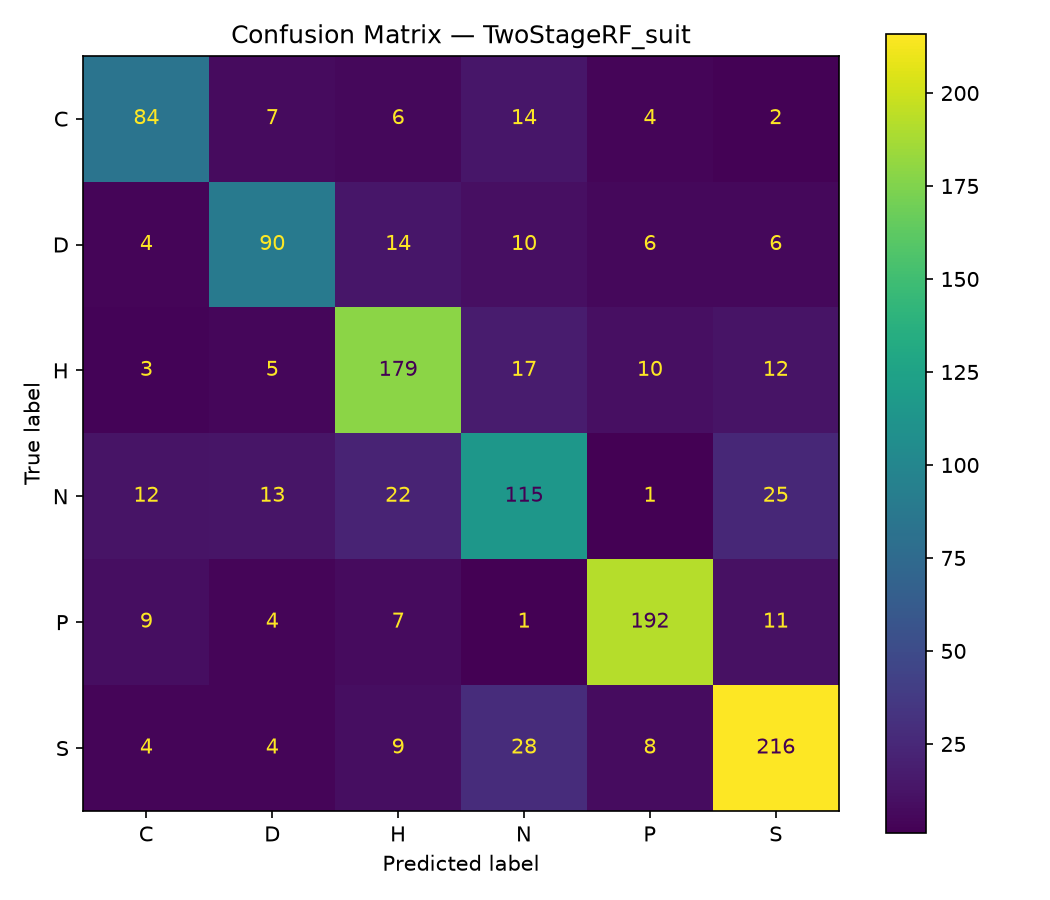

Confusion Matrix — Stage 2: Category


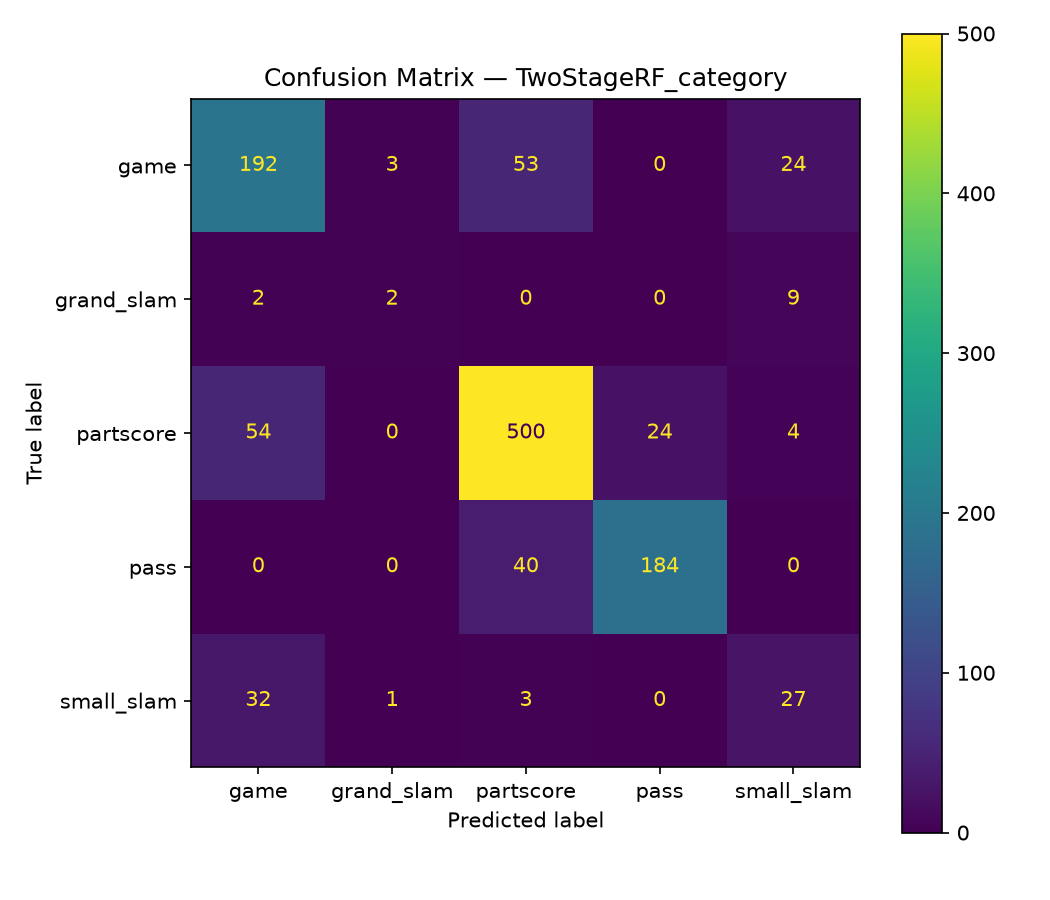

In [6]:
cm_suit_path = FIGURES_DIR / "confusion_matrix_TwoStageRF_suit.png"
cm_cat_path  = FIGURES_DIR / "confusion_matrix_TwoStageRF_category.png"

if cm_suit_path.exists():
    print("Confusion Matrix — Stage 1: Suit")
    display(Image(filename=str(cm_suit_path), width=500))
if cm_cat_path.exists():
    print("Confusion Matrix — Stage 2: Category")
    display(Image(filename=str(cm_cat_path), width=500))

## 7.6 Feature Importance

Feature Importance — Kedua Stage


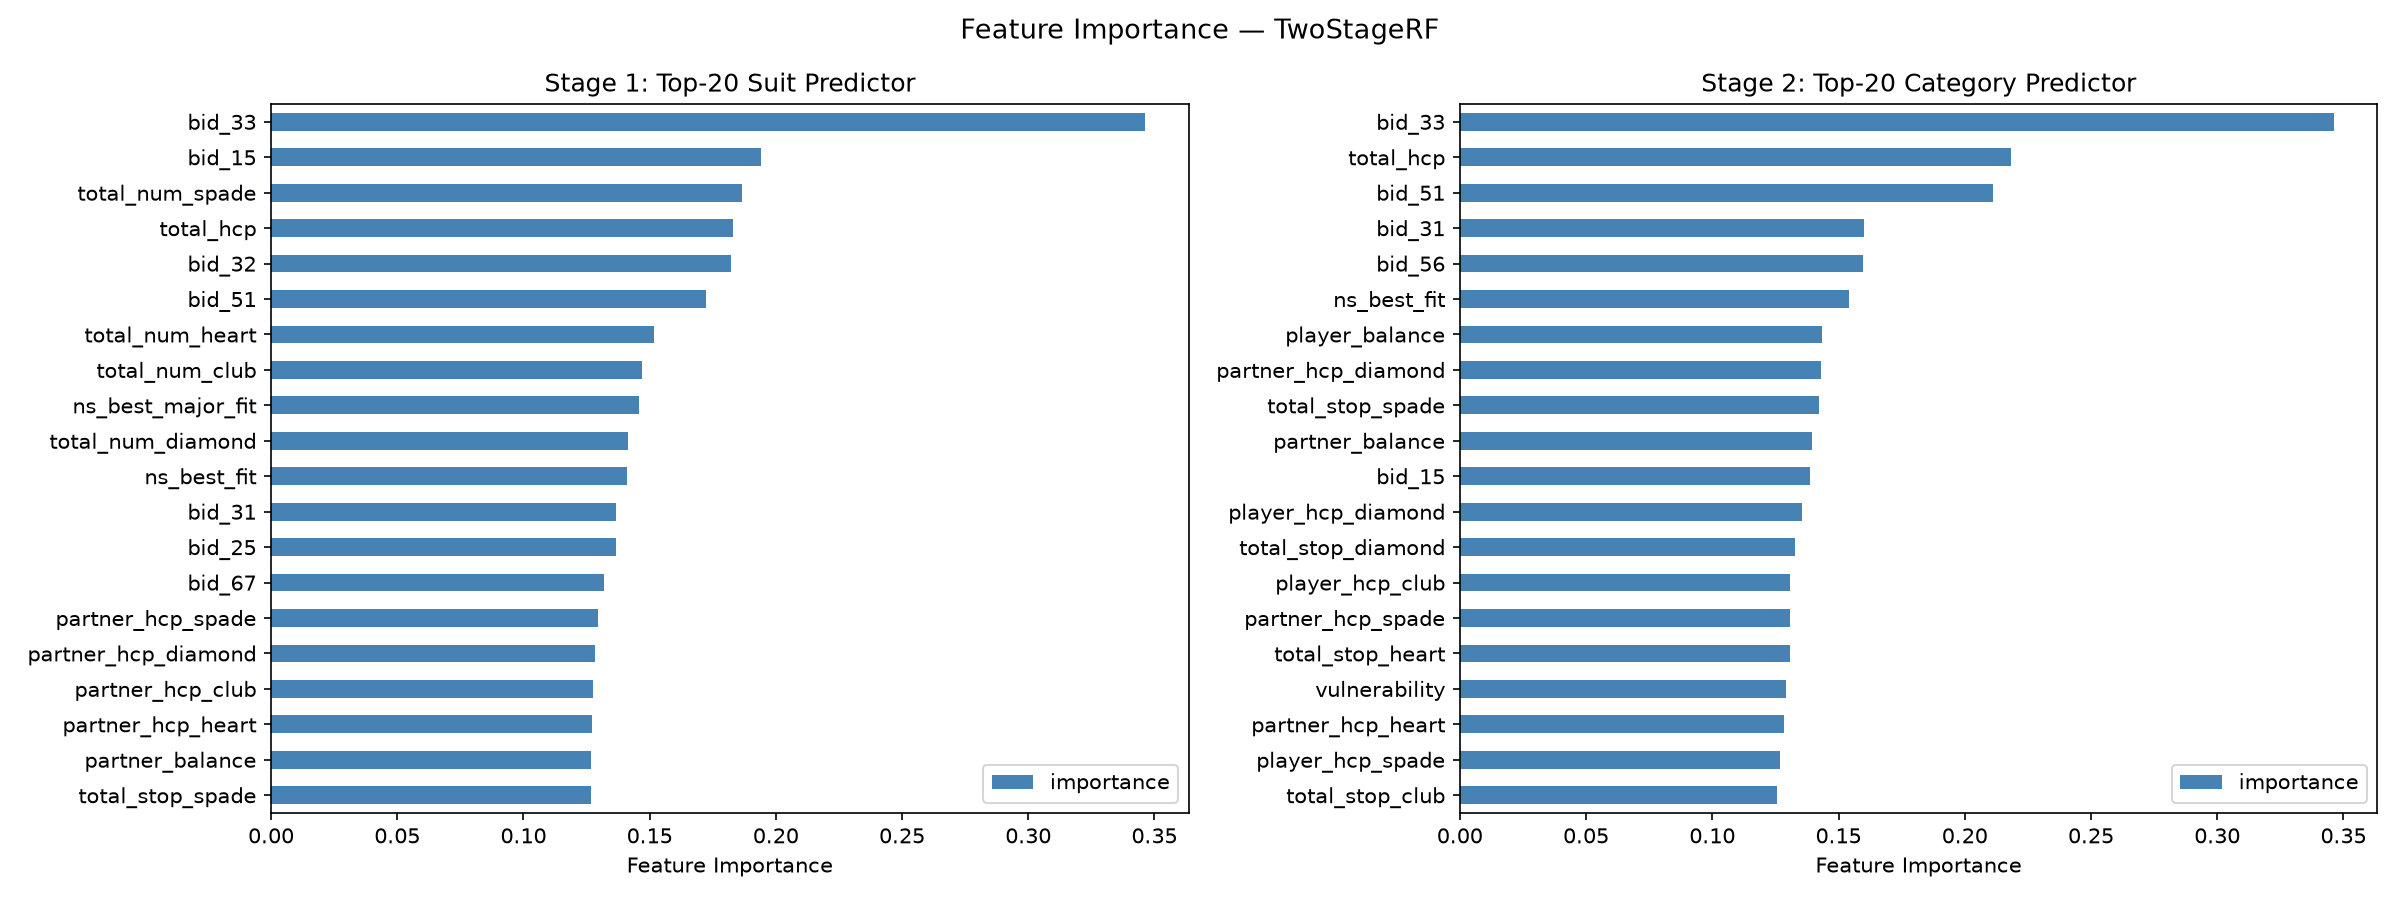

In [7]:
fi_path = FIGURES_DIR / "feature_importance_TwoStageRF.png"
if fi_path.exists():
    print("Feature Importance — Kedua Stage")
    display(Image(filename=str(fi_path), width=800))

In [8]:
imp_suit, imp_cat = model.feature_importance()
print("Top 10 Fitur Terpenting — Stage 1 (Suit):")
print(imp_suit.head(10).to_string())
print()
print("Top 10 Fitur Terpenting — Stage 2 (Category):")
print(imp_cat.head(10).to_string())

Top 10 Fitur Terpenting — Stage 1 (Suit):
                   importance
bid_33               0.346277
bid_15               0.194173
total_num_spade      0.186658
total_hcp            0.183115
bid_32               0.182404
bid_51               0.172503
total_num_heart      0.151520
total_num_club       0.147047
ns_best_major_fit    0.145651
total_num_diamond    0.141605

Top 10 Fitur Terpenting — Stage 2 (Category):
                     importance
bid_33                 0.346162
total_hcp              0.218354
bid_51                 0.211286
bid_31                 0.160225
bid_56                 0.159621
ns_best_fit            0.154233
player_balance         0.143311
partner_hcp_diamond    0.143093
total_stop_spade       0.142443
partner_balance        0.139387


## 7.7 Simpan Ringkasan Metrik

In [9]:
summary_text = f"""=== RINGKASAN EVALUASI MODEL 2-STAGE RANDOM FOREST ===
Test set     : {X_test.shape[0]} sampel
Fitur        : {X_test.shape[1]}

=== 7 INDIKATOR (C23 Tabel 4) ===
{metrics['indicators'].to_string()}

=== PERBANDINGAN DENGAN C23 PAPER ===
SC (metrik utama): {metrics['sc_accuracy']:.4f} (paper: 0.773)
SS              : {metrics['ss_accuracy']:.4f}
MS              : {metrics['ms_accuracy']:.4f}

=== F1 PER STAGE ===
Stage 1 (Suit)     F1 weighted: {metrics['suit_f1']:.4f}
Stage 2 (Category) F1 weighted: {metrics['category_f1']:.4f}
"""

summary_path = METRICS_DIR / "evaluation_summary.txt"
summary_path.write_text(summary_text, encoding="utf-8")
print(f"Ringkasan evaluasi disimpan ke: {summary_path}")
print()
print(summary_text)

Ringkasan evaluasi disimpan ke: d:\SkripsiBBO\results\metrics\evaluation_summary.txt

=== RINGKASAN EVALUASI MODEL 2-STAGE RANDOM FOREST ===
Test set     : 1154 sampel
Fitur        : 98

=== 7 INDIKATOR (C23 Tabel 4) ===
MS            0.6369
SCA           0.1473
SCU           0.0000
SSE           0.1222
O             0.0936
SC (utama)    0.7842
SS            0.7591

=== PERBANDINGAN DENGAN C23 PAPER ===
SC (metrik utama): 0.7842 (paper: 0.773)
SS              : 0.7591
MS              : 0.6369

=== F1 PER STAGE ===
Stage 1 (Suit)     F1 weighted: 0.7588
Stage 2 (Category) F1 weighted: 0.7830



---
## Output

File yang dihasilkan:
- `results/figures/confusion_matrix_TwoStageRF_*.png`
- `results/figures/feature_importance_TwoStageRF.png`
- `results/figures/indicators_TwoStageRF.png`
- `results/metrics/evaluation_summary.txt`
- `results/metrics/classification_report_TwoStageRF.txt`

**Langkah berikutnya:** Buka `08_analisis.ipynb` untuk analisis mendalam hasil.